# Zentra Dataset Builder

For LightGBM + Prophet Modelling

In [ ]:
# imports

%matplotlib inline
import warnings, re, os, time
from pathlib import Path

import requests
import pandas as pd
import numpy as np
import h3
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', font_scale=1.0)

BLUE, ORANGE, RED, GREEN, PURPLE = '#1a6bff', '#f59e0b', '#ef4444', '#22c55e', '#8b5cf6'
PERIOD_COLORS = {'AM': BLUE, 'MD': ORANGE, 'PM': GREEN}
PERIOD_ORDER = ['AM', 'MD', 'PM']

print(f'h3 version: {h3.__version__}')

h3 version: 4.5.0


In [ ]:
# Directory layout 
# raw/       → downloaded files 
# processed/ → intermediate cleaned files
# master/    → final ML-ready CSVs
# plots/     → saved charts

DATA = Path('../data')
RAW = DATA / 'raw';       RAW.mkdir(parents=True, exist_ok=True)
PROC = DATA / 'processed'; PROC.mkdir(parents=True, exist_ok=True)
MASTER = DATA / 'master';    MASTER.mkdir(parents=True, exist_ok=True)
PLOTS = DATA / 'plots';     PLOTS.mkdir(parents=True, exist_ok=True)

print('Directories ready.')

Directories ready.


In [6]:
# Global config 

H3_RES = 8   # Resolution 8 hexagons are ~460 m across — good city-block level

# These are the three time windows DOT uses for their counts
PERIOD_WINDOWS = {
    'AM': range(7, 10),   # Morning rush: 7–9 AM
    'MD': range(11, 14),  # Midday:       11 AM – 1 PM
    'PM': range(16, 19),  # Evening rush: 4–6 PM
}

def hour_to_period(hour):
    """Map an hour (0-23) to AM / MD / PM, or None if outside windows."""
    for period, hrs in PERIOD_WINDOWS.items():
        if hour in hrs:
            return period
    return None

# Manhattan TLC zone IDs — we use these to filter taxi trips to Manhattan only
MANHATTAN_ZONES = {
    4, 12, 13, 24, 41, 42, 43, 45, 48, 50, 68, 74, 75, 79, 87, 88, 90, 100,
    103, 104, 105, 107, 113, 114, 116, 120, 125, 127, 128, 137, 140, 141, 142,
    143, 144, 148, 151, 152, 153, 158, 161, 162, 163, 164, 166, 170, 186, 194,
    202, 209, 211, 224, 229, 230, 231, 232, 233, 234, 236, 237, 238, 239, 243,
    244, 246, 249, 261, 262, 263,
}

# Month name - month number (DOT column names use short month names)
MONTH_MAP = {'May': 5, 'Sept': 9, 'Oct': 10, 'June': 6, 'Mar': 3}

# Socrata (NYC Open Data) base URL
SOCRATA_BASE = 'https://data.cityofnewyork.us/resource'


## Helpers Functions

Two functions we'll call after loading every dataset:
- **`dqr()`** — prints a quick summary box (rows, columns, nulls, date range)
- **`dqp()`** — returns a per-column stats table (dtype, nulls, min/max/mean/unique)

In [7]:
def dqr(name, df, date_col=None):
    """Data Quality Report — prints a summary banner for the dataframe."""
    n_null = int(df.isnull().sum().sum())
    null_pct = n_null / df.size * 100 if df.size else 0
    print(f'DATA QUALITY REPORT — {name:<38}')
    print(f'Rows:       {df.shape[0]:>10,}')
    print(f'Columns:    {df.shape[1]:>10,}')
    null_str = f'{n_null:,} ({null_pct:.2f}%)'
    print(f'Null cells: {null_str:<50}')
    if date_col and date_col in df.columns and len(df):
        lo = str(df[date_col].min())[:10]
        hi = str(df[date_col].max())[:10]
        print(f'Date range: {lo}  →  {hi}')


def dqp(df):
    """Data Quality Profile — per-column stats table."""
    rows = []
    for col in df.columns:
        s = df[col]
        n_null = s.isna().sum()
        row = {
            'column': col,
            'dtype': str(s.dtype),
            'null_count': int(n_null),
            'null_pct': round(n_null / len(df) * 100, 2) if len(df) else 0,
            'unique': int(s.nunique()),
        }
        if pd.api.types.is_numeric_dtype(s) and n_null < len(df):
            row.update({
                'min': round(float(s.min()),    3),
                'mean': round(float(s.mean()),   3),
                'median': round(float(s.median()), 3),
                'max': round(float(s.max()),    3),
            })
        rows.append(row)
    return pd.DataFrame(rows).set_index('column')


def norm_score(x):
    """Normalise a series to 0-100 using z-score clipped at +3 0r -3."""
    z = (x - x.mean()) / (x.std() + 1e-6)
    return ((z.clip(-3, 3) + 3) / 6 * 100).round(2)


def save_dqp(df, name):
    """Save a DQP table to CSV and print where it went."""
    path = PROC / f'dqp_{name}.csv'
    dqp(df).to_csv(path)
    print(f'  DQP saved - {path}')


print('DQR / DQP helpers ready.')

DQR / DQP helpers ready.


## 1 · Pedestrian Location Geocoding

The DOT dataset has 36 survey corridors in Manhattan (Broadway, 5th Ave, 34th St crosstown, etc.).
We need lat/lon coordinates for each one so we can assign them to H3 hexagons.

This lookup table was built from the DOT corridor descriptions — hardcoded here so there's
no API dependency, but cross-checked against Google Maps for accuracy.

In [8]:
# Lat/lon for each of the 36 DOT survey corridors.
# Format: location_id → (lat, lon, description)
LOCATION_COORDS = {
    # Broadway corridor (north–south spine of Manhattan)
    101: (40.7082, -74.0111, 'Broadway & Fulton St (Financial District)'),
    102: (40.7127, -74.0059, 'Broadway & Chambers St'),
    103: (40.7191, -74.0013, 'Broadway & Canal St (Chinatown)'),
    104: (40.7254, -73.9982, 'Broadway & Houston St (SoHo)'),
    105: (40.7296, -73.9965, 'Broadway & Prince St (SoHo)'),
    106: (40.7352, -73.9903, 'Broadway & 14th St (Union Square)'),
    107: (40.7410, -73.9893, 'Broadway & 18th St (Flatiron)'),
    108: (40.7428, -73.9882, 'Broadway & 23rd St'),
    109: (40.7503, -73.9882, 'Broadway & 34th St (Herald Square)'),
    110: (40.7550, -73.9869, 'Broadway & 38th St (Garment District)'),
    111: (40.7580, -73.9855, 'Broadway & 42nd St (Times Square)'),
    112: (40.7612, -73.9832, 'Broadway & 47th St (Times Square North)'),
    113: (40.7645, -73.9818, 'Broadway & 57th St'),
    114: (40.7782, -73.9814, 'Broadway & 72nd St (Upper West Side)'),
    115: (40.7950, -73.9727, 'Broadway & 96th St'),
    # 5th Avenue corridor
    201: (40.7484, -73.9858, '5th Ave & 34th St (Empire State Building)'),
    202: (40.7531, -73.9822, '5th Ave & 42nd St (Bryant Park)'),
    203: (40.7580, -73.9768, '5th Ave & 49th St (Rockefeller Center)'),
    204: (40.7628, -73.9737, '5th Ave & 57th St'),
    205: (40.7696, -73.9684, '5th Ave & 66th St (Museum Mile)'),
    206: (40.7733, -73.9654, '5th Ave & 72nd St'),
    # 34th St crosstown
    301: (40.7516, -73.9990, '34th St & 8th Ave (Penn Station)'),
    302: (40.7487, -73.9763, '34th St & Lex Ave (Midtown East)'),
    # 42nd St crosstown
    401: (40.7561, -73.9949, '42nd St & 8th Ave (Port Authority)'),
    402: (40.7518, -73.9757, '42nd St & Lex Ave (Grand Central)'),
    # 14th St crosstown
    501: (40.7406, -73.9992, '14th St & 8th Ave (Chelsea Market)'),
    502: (40.7388, -73.9879, '14th St & 6th Ave'),
    # East Midtown / Lexington Ave
    601: (40.7601, -73.9694, 'Lex Ave & 57th St'),
    602: (40.7540, -73.9734, 'Park Ave & 47th St (Grand Central area)'),
    # Lower Manhattan
    701: (40.7069, -74.0113, 'Wall St & Broadway'),
    702: (40.7021, -74.0131, 'Rector St & Broadway'),
    # Midtown West / Hell's Kitchen
    801: (40.7614, -73.9897, '57th St & 9th Ave'),
    # Harlem
    901: (40.8116, -73.9465, '125th St & Lenox Ave (Harlem)'),
    902: (40.8076, -73.9504, '125th St & Adam Clayton Powell Blvd'),
    903: (40.8048, -73.9572, '125th St & 7th Ave'),
}

# Build a dataframe and assign an H3 cell to each location
loc_df = pd.DataFrame([
    {'location_id': lid, 'lat': lat, 'lon': lon, 'description': desc}
    for lid, (lat, lon, desc) in LOCATION_COORDS.items()
])
loc_df['h3_cell'] = loc_df.apply(
    lambda r: h3.latlng_to_cell(r['lat'], r['lon'], H3_RES), axis=1
)

# Save it
loc_df.to_csv(PROC / 'location_geocoded.csv', index=False)

print(f'Geocoded {len(loc_df)} Manhattan survey locations')
print(f'Unique H3 cells at resolution {H3_RES}: {loc_df["h3_cell"].nunique()}')
print(f'(Some corridors share a cell — that is normal at 460 m resolution)')
display(loc_df.head(8))

Geocoded 35 Manhattan survey locations
Unique H3 cells at resolution 8: 22
(Some corridors share a cell — that is normal at 460 m resolution)


,location_id,lat,lon,description,h3_cell
0,101,40.708,-74.011,Broadway & Fulton St (Financial District),882a107289fffff
1,102,40.713,-74.006,Broadway & Chambers St,882a107289fffff
2,103,40.719,-74.001,Broadway & Canal St (Chinatown),882a1072c1fffff
3,104,40.725,-73.998,Broadway & Houston St (SoHo),882a1072c1fffff
4,105,40.730,-73.996,Broadway & Prince St (SoHo),882a1072c9fffff
5,106,40.735,-73.990,Broadway & 14th St (Union Square),882a100d23fffff
6,107,40.741,-73.989,Broadway & 18th St (Flatiron),882a100d21fffff
7,108,40.743,-73.988,Broadway & 23rd St,882a100d21fffff


## 2 · Pedestrian Counts — All Historical Survey Dates (2007–2025)

The NYC DOT runs a bi-annual pedestrian count along major Manhattan corridors.
The CSV has one row per corridor, with columns like `May07_AM`, `Sept10_PM`, etc.
Need to reshape it from **wide** (one column per survey × period) to **long**
(one row per corridor × survey date × period).

**Need to download the CSV first:**
1. Go to https://data.cityofnewyork.us/Transportation/Bi-Annual-Pedestrian-Counts/2de4-3jh6
2. Click "Export → CSV"
3. Save it as `Bi-Annual_Pedestrian_Counts.csv` in the same folder as this notebook

Or update `PED_CSV_PATH` below to point to wherever I have saved it.

In [9]:
# Load the raw CSV 

PED_CSV_PATH = RAW / 'Bi-Annual_Pedestrian_Counts_20260614.csv'  

ped_raw = pd.read_csv(PED_CSV_PATH)

# Fix a common typo in column names (pM → PM)
ped_raw.columns = [c.replace('_pM', '_PM') for c in ped_raw.columns]

# Identify the count columns — they look like "May07_AM", "Sept19_PM", "Oct22_MD"
meta_cols = ['Loc', 'Borough', 'Street_Nam', 'From_Stree', 'To_Street']
count_cols = [c for c in ped_raw.columns if re.match(r'[A-Za-z]+\d{2}_(AM|PM|MD)', c)]

print(f'Raw shape: {ped_raw.shape}')
print(f'Boroughs:  {ped_raw["Borough"].value_counts().to_dict()}')
print(f'Found {len(count_cols)} count columns (survey x period combos)')
print(f'Sample column names: {count_cols[:6]}')

Raw shape: (114, 116)
Boroughs:  {'Manhattan': 36, 'Brooklyn': 26, 'Queens': 25, 'Harlem River Bridges': 9, 'Bronx': 8, 'Staten Isla': 5, 'East River Bridges': 5}
Found 108 count columns (survey x period combos)
Sample column names: ['May07_AM', 'May07_PM', 'May07_MD', 'Sept07_AM', 'Sept07_PM', 'Sept07_MD']


In [10]:
# Reshape wide → long, Manhattan only 
# For each corridor row, we loop through every count column, parse the
# season + year + period out of the column name, and emit one long row.

ped_man = ped_raw[ped_raw['Borough'] == 'Manhattan'].copy()
print(f'Manhattan corridors: {len(ped_man)}')

long_rows = []
for _, row in ped_man.iterrows():
    for col in count_cols:
        m = re.match(r'([A-Za-z]+)(\d{2})_(AM|PM|MD)', col)
        if not m:
            continue
        season, yy, period = m.groups()
        val = row[col]
        if pd.isna(val):
            continue
        # Clean up numbers that might be stored as strings with commas
        val = float(str(val).replace(',', ''))
        if val < 0:
            continue  # Skip negative counts (data errors)
        year  = 2000 + int(yy)
        month = MONTH_MAP.get(season)
        if month is None:
            continue  # Skip seasons we don't recognise
        # DOT surveys happen on the 15th of the month
        survey_date = f'{year:04d}-{month:02d}-15'
        long_rows.append({
            'location_id': row['Loc'],
            'street': row['Street_Nam'],
            'from_street': row['From_Stree'],
            'to_street': row['To_Street'],
            'borough': row['Borough'],
            'survey_date': survey_date,
            'year': year,
            'month': month,
            'season': season,
            'period': period,
            'pedestrians': val,
        })

ped_long = pd.DataFrame(long_rows)
ped_long['survey_date'] = pd.to_datetime(ped_long['survey_date'])
ped_long = ped_long.sort_values(['location_id', 'survey_date', 'period']).reset_index(drop=True)

ped_long.to_csv(PROC / 'pedestrian_long.csv', index=False)

print(f'Long format shape: {ped_long.shape}')
print(f'Survey dates found: {sorted(ped_long["survey_date"].dt.strftime("%Y-%m").unique())}')
print(f'Unique locations: {ped_long["location_id"].nunique()}')

Manhattan corridors: 36
Long format shape: (3826, 11)
Survey dates found: ['2007-05', '2007-09', '2008-05', '2008-09', '2009-05', '2009-09', '2010-05', '2010-09', '2011-05', '2011-09', '2012-05', '2012-09', '2013-05', '2013-09', '2014-05', '2014-09', '2015-05', '2015-09', '2016-05', '2016-09', '2017-05', '2017-09', '2018-05', '2018-09', '2019-05', '2020-10', '2021-05', '2021-10', '2022-05', '2022-10', '2023-05', '2023-10', '2024-06', '2024-10', '2025-05', '2025-10']
Unique locations: 36


In [11]:
# Attach H3 cells and compute a normalised score 

ped_long = ped_long.merge(
    loc_df[['location_id', 'lat', 'lon', 'h3_cell', 'description']],
    on='location_id',
    how='left'
)

n_matched = ped_long['h3_cell'].notna().sum()
n_unmatched = ped_long['h3_cell'].isna().sum()
print(f'Rows with H3 cell: {n_matched:,} ({n_matched/len(ped_long)*100:.1f}%)')
print(f'Rows without H3 cell: {n_unmatched:,}')

if n_unmatched > 0:
    missing = ped_long.loc[ped_long['h3_cell'].isna(), 'location_id'].unique()
    print(f' Missing location IDs: {missing} — add them to LOCATION_COORDS in Section 1')

# Normalised pedestrian score (0–100) relative to all locations on the same date × period
# Useful as a relative density measure for modelling
ped_long['ped_score']   = ped_long.groupby(['survey_date', 'period'])['pedestrians'].transform(norm_score)
ped_long['day_of_week'] = ped_long['survey_date'].dt.dayofweek

ped_long.to_csv(PROC / 'pedestrian_long_h3.csv', index=False)
print(f'Saved → {PROC / "pedestrian_long_h3.csv"}')

dqr('Pedestrian counts — all survey dates', ped_long, date_col='survey_date')

Rows with H3 cell: 0 (0.0%)
Rows without H3 cell: 3,826
 Missing location IDs: [35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58
 59 60 61 62 63 64 65 66 67 68 69 70] — add them to LOCATION_COORDS in Section 1
Saved → ..\data\processed\pedestrian_long_h3.csv
DATA QUALITY REPORT — Pedestrian counts — all survey dates  
Rows:            3,826
Columns:            17
Null cells: 15,304 (23.53%)                                   
Date range: 2007-05-15  →  2025-10-15


In [12]:
# DQP on pedestrian data 

display(dqp(ped_long))
save_dqp(ped_long, 'pedestrian')

,dtype,null_count,null_pct,unique,min,mean,median,max
column,,,,,,,,
location_id,int64,0,0.000,36,35.000,52.443,52.000,70.000
street,object,0,0.000,28,NaN,NaN,NaN,NaN
from_street,object,0,0.000,24,NaN,NaN,NaN,NaN
to_street,object,0,0.000,24,NaN,NaN,NaN,NaN
borough,object,0,0.000,1,NaN,NaN,NaN,NaN
survey_date,datetime64[ns],0,0.000,36,NaN,NaN,NaN,NaN
year,int64,0,0.000,19,2007.000,2015.746,2015.000,2025.000
month,int64,0,0.000,4,5.000,7.212,9.000,10.000
season,object,0,0.000,4,NaN,NaN,NaN,NaN


  DQP saved - ..\data\processed\dqp_pedestrian.csv


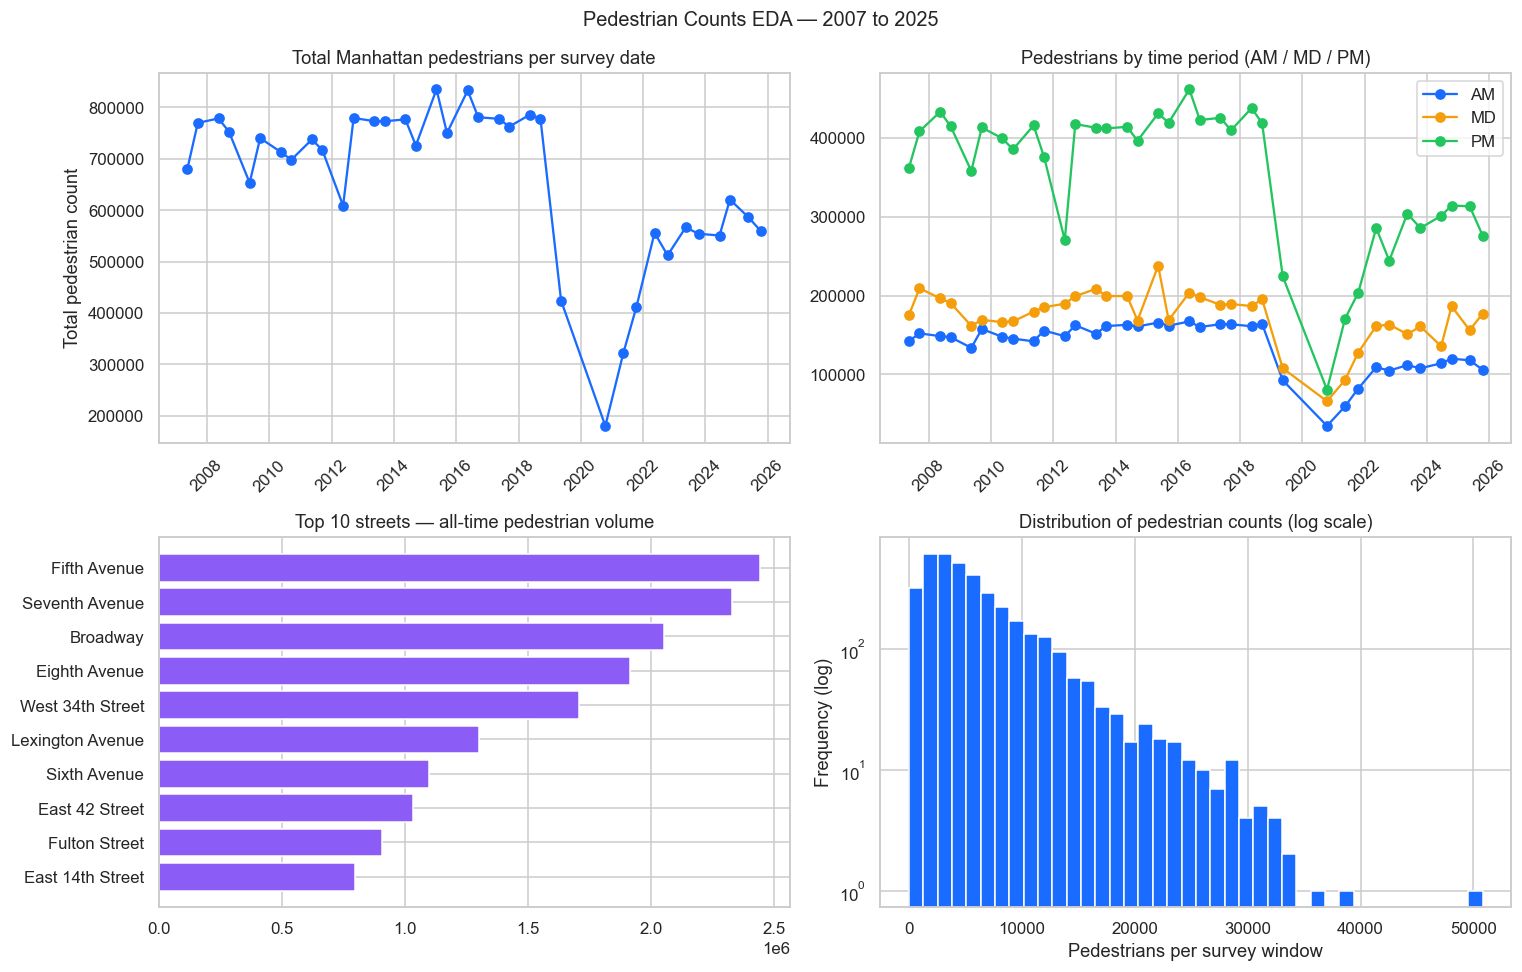

Key facts:
 36 survey dates, 36 locations, 3,826 rows total
 Count range: 0 to 50,827
 Most-counted street: Fifth Avenue (2,440,867 all-time)


In [13]:
# EDA — what do the pedestrian counts look like? 

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Total Manhattan pedestrians per survey date (all periods summed)
date_totals = ped_long.groupby('survey_date')['pedestrians'].sum().reset_index()
axes[0, 0].plot(date_totals['survey_date'], date_totals['pedestrians'], 'o-', color=BLUE)
axes[0, 0].set_title('Total Manhattan pedestrians per survey date')
axes[0, 0].set_ylabel('Total pedestrian count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Breakdown by period over time
period_year = ped_long.groupby(['survey_date', 'period'])['pedestrians'].sum().reset_index()
for p in PERIOD_ORDER:
    sub = period_year[period_year['period'] == p]
    axes[0, 1].plot(sub['survey_date'], sub['pedestrians'], 'o-',
                    label=p, color=PERIOD_COLORS[p])
axes[0, 1].set_title('Pedestrians by time period (AM / MD / PM)')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=45)

# Top 10 streets by all-time total volume
top_streets = ped_long.groupby('street')['pedestrians'].sum().nlargest(10)
axes[1, 0].barh(top_streets.index, top_streets.values, color=PURPLE)
axes[1, 0].invert_yaxis()
axes[1, 0].set_title('Top 10 streets — all-time pedestrian volume')

# Distribution of counts (log scale because it is very skewed)
axes[1, 1].hist(ped_long['pedestrians'], bins=40, color=BLUE, edgecolor='white', log=True)
axes[1, 1].set_title('Distribution of pedestrian counts (log scale)')
axes[1, 1].set_xlabel('Pedestrians per survey window')
axes[1, 1].set_ylabel('Frequency (log)')

plt.suptitle('Pedestrian Counts EDA — 2007 to 2025', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS / 'eda_pedestrian_trends.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Key facts:')
print(f' {ped_long["survey_date"].nunique()} survey dates, {ped_long["location_id"].nunique()} locations, {len(ped_long):,} rows total')
print(f' Count range: {ped_long["pedestrians"].min():.0f} to {ped_long["pedestrians"].max():,.0f}')
print(f' Most-counted street: {top_streets.idxmax()} ({top_streets.max():,.0f} all-time)')

## 3 · TLC Trips — Yellow Taxi + Uber/Lyft (HVFHV)

This is the big one. We pull two datasets from NYC Open Data:

- **Yellow Taxi** (`m6nq-qud6`) — traditional yellow cabs
- **HVFHV** (`23pu-xa2h`) — High Volume FHV = Uber, Lyft, Via

Both use `PULocationID` (the TLC zone number), so first build a lookup table
that maps each zone ID to an H3 hexagon using zone centroid coordinates.
Then we aggregate trips to `(h3_cell, period)` for each survey month.

### Why both Yellow and HVFHV?
By ~2023 HVFHV trips outnumber Yellow trips in Manhattan 3:1.
Using only yellow taxis would badly under-count actual vehicle-based demand.

In [14]:
# TLC zone → H3 centroid lookup 
# These are the approximate centroids of each Manhattan TLC zone.
# Source: TLC zone shapefile centroids (https://www.nyc.gov/site/tlc)

TLC_ZONE_CENTROIDS = {
    4:   (40.7282, -74.0027, 'Alphabet City / East Village'),
    12:  (40.7614, -73.9914, 'Columbus Circle / Hell\'s Kitchen'),
    13:  (40.7529, -73.9895, 'Hudson Yards'),
    24:  (40.7135, -74.0083, 'Battery Park'),
    41:  (40.7517, -73.9757, 'Central Midtown'),
    42:  (40.7648, -73.9808, 'Central Park South'),
    43:  (40.7806, -73.9789, 'Central Park West'),
    45:  (40.7127, -74.0059, 'City Hall / Civic Center'),
    48:  (40.7412, -74.0003, 'Chelsea'),
    50:  (40.7210, -74.0045, 'Chinatown'),
    68:  (40.8071, -73.9642, 'East Harlem'),
    74:  (40.7248, -73.9956, 'East Village'),
    75:  (40.7189, -73.9893, 'Lower East Side'),
    79:  (40.7464, -73.9786, 'East Midtown'),
    87:  (40.7692, -73.9838, 'Upper West Side'),
    88:  (40.7801, -73.9720, 'Upper West Side North'),
    90:  (40.7412, -74.0082, 'Meatpacking District'),
    100: (40.7546, -73.9925, 'Garment District'),
    103: (40.7362, -74.0012, 'Greenwich Village'),
    104: (40.7390, -74.0083, 'West Village'),
    105: (40.7328, -74.0033, 'Greenwich Village South'),
    107: (40.8011, -73.9537, 'Harlem'),
    113: (40.7628, -73.9661, 'Lenox Hill'),
    114: (40.7756, -73.9588, 'Lincoln Square'),
    116: (40.7490, -73.9880, 'Midtown Center'),
    120: (40.7565, -73.9936, 'Midtown North'),
    125: (40.7445, -73.9892, 'Midtown South'),
    127: (40.7485, -73.9742, 'Murray Hill'),
    128: (40.7424, -73.9793, 'Kips Bay / NoMad'),
    137: (40.7116, -74.0121, 'Financial District North'),
    140: (40.7076, -74.0128, 'Financial District South'),
    141: (40.7047, -74.0131, 'Financial District South'),
    142: (40.7566, -73.9867, 'Lincoln Square'),
    143: (40.7620, -73.9795, 'Upper East Side South'),
    144: (40.7698, -73.9627, 'Upper East Side North'),
    148: (40.7413, -73.9889, 'Flatiron / Madison Sq'),
    151: (40.8200, -73.9503, 'Inwood'),
    152: (40.8280, -73.9418, 'Marble Hill'),
    153: (40.7898, -73.9756, 'Manhattan Valley'),
    158: (40.7533, -73.9784, 'Midtown East'),
    161: (40.7585, -73.9921, 'Midtown West'),
    162: (40.7579, -73.9965, 'Hell\'s Kitchen South'),
    163: (40.7686, -73.9907, 'Lincoln Center'),
    164: (40.7706, -73.9796, 'Upper West Side Central'),
    166: (40.7560, -73.9836, 'Midtown East North'),
    170: (40.7312, -74.0048, 'Hudson Square'),
    186: (40.7143, -73.9966, 'Little Italy / NoLiTa'),
    194: (40.7459, -74.0073, 'Hudson Yards South'),
    202: (40.7531, -73.9822, '5th Ave / Bryant Park'),
    209: (40.7213, -74.0109, 'Tribeca / Civic Center'),
    211: (40.7095, -74.0095, 'World Trade Center'),
    224: (40.7281, -74.0036, 'SoHo'),
    229: (40.7196, -73.9999, 'Lower East Side North'),
    230: (40.7141, -73.9948, 'Two Bridges / Seaport'),
    231: (40.7044, -74.0117, 'Battery Park City'),
    232: (40.7068, -74.0164, 'Greenwich St South'),
    233: (40.7150, -74.0082, 'Washington St'),
    234: (40.7223, -74.0069, 'Tribeca North'),
    236: (40.8100, -73.9557, 'Central Harlem North'),
    237: (40.8060, -73.9530, 'Central Harlem South'),
    238: (40.8142, -73.9467, 'East Harlem North'),
    239: (40.7970, -73.9454, 'Yorkville East'),
    243: (40.7786, -73.9528, 'Yorkville West'),
    244: (40.7842, -73.9532, 'Upper East Side Far North'),
    246: (40.7893, -73.9672, 'Upper West Side Far North'),
    249: (40.7812, -73.9792, 'Riverside Side South'),
    261: (40.7561, -73.9949, 'Theater District / Times Square'),
    262: (40.7530, -73.9780, 'Turtle Bay / United Nations'),
    263: (40.7480, -73.9720, 'Kips Bay East'),
}

# Build a zone dataframe with H3 cells
zone_df = pd.DataFrame([
    {'zone_id': zid, 'lat': lat, 'lon': lon, 'neighborhood': name}
    for zid, (lat, lon, name) in TLC_ZONE_CENTROIDS.items()
])
zone_df['h3_cell'] = zone_df.apply(
    lambda r: h3.latlng_to_cell(r['lat'], r['lon'], H3_RES), axis=1
)
zone_df.to_csv(PROC / 'tlc_zone_h3_lookup.csv', index=False)

print(f'TLC zone lookup: {len(zone_df)} Manhattan zones → {zone_df["h3_cell"].nunique()} unique H3 cells')
display(zone_df.head(5))

TLC zone lookup: 69 Manhattan zones → 38 unique H3 cells


,zone_id,lat,lon,neighborhood,h3_cell
0,4,40.728,-74.003,Alphabet City / East Village,882a1072cdfffff
1,12,40.761,-73.991,Columbus Circle / Hell's Kitchen,882a10725bfffff
2,13,40.753,-73.990,Hudson Yards,882a100d2dfffff
3,24,40.714,-74.008,Battery Park,882a107289fffff
4,41,40.752,-73.976,Central Midtown,882a100d63fffff


### 3.1 · Download functions — Yellow Taxi and HVFHV

Define two separate fetch functions (one per vehicle type) and then a combiner.
Both hit the NYC Open Data Socrata API, which lets filter by month, zone, and hour
without downloading the full dataset (which is tens of millions of rows per month).

**Caching:** once a month is downloaded it is saved as CSV. If you re-run the notebook,
it just reads from cache — no re-downloading.

In [15]:
# Fetch Yellow Taxi for one survey month 
# Yellow taxi dataset: https://data.cityofnewyork.us/resource/m6nq-qud6
# Pickup timestamp:    tpep_pickup_datetime
# Zone ID:             PULocationID

def fetch_yellow_month(year, month):
    """
    Pull Yellow taxi trips for the given year-month from NYC Open Data.
    Filters to Manhattan zones and AM/MD/PM hour windows.
    Returns a tidy dataframe with standardised columns, or None on failure.
    """
    if year < 2009:
        # TLC open data only goes back to 2009
        return None

    cache = RAW / f'yellow_{year}_{month:02d}.csv'
    if cache.exists():
        df = pd.read_csv(cache)
        df['pickup_dt'] = pd.to_datetime(df['pickup_dt'])
        return df

    date_lo = f'{year}-{month:02d}-01T00:00:00'
    date_hi = f'{year}-{month:02d}-28T23:59:59'
    zone_str = ','.join(str(z) for z in MANHATTAN_ZONES)
    hour_filter = (
        "(date_extract_hh(tpep_pickup_datetime) >= 7 AND date_extract_hh(tpep_pickup_datetime) <= 9)"
        " OR (date_extract_hh(tpep_pickup_datetime) >= 11 AND date_extract_hh(tpep_pickup_datetime) <= 13)"
        " OR (date_extract_hh(tpep_pickup_datetime) >= 16 AND date_extract_hh(tpep_pickup_datetime) <= 18)"
    )

    params = {
        '$select': 'tpep_pickup_datetime,PULocationID,fare_amount,trip_distance',
        '$where': (
            f"tpep_pickup_datetime >= '{date_lo}' "
            f"AND tpep_pickup_datetime <= '{date_hi}' "
            f"AND PULocationID IN ({zone_str}) "
            f"AND ({hour_filter})"
        ),
        '$limit': 200000,
        '$order': 'tpep_pickup_datetime',
    }

    try:
        r = requests.get(f'{SOCRATA_BASE}/m6nq-qud6.json', params=params, timeout=120)
        r.raise_for_status()
        df = pd.DataFrame(r.json())
    except Exception as e:
        print(f'    Yellow fetch error: {e}')
        return None

    if df.empty:
        return None

    df = df.rename(columns={'tpep_pickup_datetime': 'pickup_dt'})
    df['pickup_dt'] = pd.to_datetime(df['pickup_dt'], errors='coerce')
    df['PULocationID'] = pd.to_numeric(df['PULocationID'], errors='coerce')
    df['fare_amount'] = pd.to_numeric(df['fare_amount'],  errors='coerce')
    df['trip_distance']= pd.to_numeric(df['trip_distance'],errors='coerce')
    df['vehicle_type'] = 'yellow'
    df = df.dropna(subset=['pickup_dt', 'PULocationID'])
    df = df[df['PULocationID'].isin(MANHATTAN_ZONES)]

    df.to_csv(cache, index=False)
    return df


print('Yellow taxi fetch function defined.')

Yellow taxi fetch function defined.


In [16]:
# Fetch HVFHV (Uber/Lyft) for one survey month 
# HVFHV dataset: https://data.cityofnewyork.us/resource/23pu-xa2h
# Pickup timestamp: pickup_datetime
# Zone ID:          PULocationID
# Fare field:       base_passenger_fare
# Distance field:   trip_miles

def fetch_hvfhv_month(year, month):
    """
    Pull HVFHV (Uber/Lyft) trips for the given year-month from NYC Open Data.
    Filters to Manhattan zones and AM/MD/PM hour windows.
    Returns a tidy dataframe with standardised columns, or None on failure.

    HVFHV data starts from Feb 2019.
    """
    if year < 2019 or (year == 2019 and month < 2):
        # HVFHV open data only starts in Feb 2019
        return None

    cache = RAW / f'hvfhv_{year}_{month:02d}.csv'
    if cache.exists():
        df = pd.read_csv(cache)
        df['pickup_dt'] = pd.to_datetime(df['pickup_dt'])
        return df

    date_lo = f'{year}-{month:02d}-01T00:00:00'
    date_hi = f'{year}-{month:02d}-28T23:59:59'
    zone_str = ','.join(str(z) for z in MANHATTAN_ZONES)
    hour_filter = (
        "(date_extract_hh(pickup_datetime) >= 7 AND date_extract_hh(pickup_datetime) <= 9)"
        " OR (date_extract_hh(pickup_datetime) >= 11 AND date_extract_hh(pickup_datetime) <= 13)"
        " OR (date_extract_hh(pickup_datetime) >= 16 AND date_extract_hh(pickup_datetime) <= 18)"
    )

    params = {
        '$select': 'pickup_datetime,PULocationID,base_passenger_fare,trip_miles',
        '$where': (
            f"pickup_datetime >= '{date_lo}' "
            f"AND pickup_datetime <= '{date_hi}' "
            f"AND PULocationID IN ({zone_str}) "
            f"AND ({hour_filter})"
        ),
        '$limit': 200000,
        '$order': 'pickup_datetime',
    }

    try:
        r = requests.get(f'{SOCRATA_BASE}/23pu-xa2h.json', params=params, timeout=180)
        r.raise_for_status()
        df = pd.DataFrame(r.json())
    except Exception as e:
        print(f'    HVFHV fetch error: {e}')
        return None

    if df.empty:
        return None

    # Standardise column names to match yellow taxi schema
    df = df.rename(columns={
        'pickup_datetime':    'pickup_dt',
        'base_passenger_fare': 'fare_amount',
        'trip_miles':          'trip_distance',
    })
    df['pickup_dt'] = pd.to_datetime(df['pickup_dt'],  errors='coerce')
    df['PULocationID'] = pd.to_numeric(df['PULocationID'],errors='coerce')
    df['fare_amount'] = pd.to_numeric(df['fare_amount'], errors='coerce')
    df['trip_distance']= pd.to_numeric(df['trip_distance'],errors='coerce')
    df['vehicle_type'] = 'hvfhv'
    df = df.dropna(subset=['pickup_dt', 'PULocationID'])
    df = df[df['PULocationID'].isin(MANHATTAN_ZONES)]

    df.to_csv(cache, index=False)
    return df


print('HVFHV (Uber/Lyft) fetch function defined.')

HVFHV (Uber/Lyft) fetch function defined.


In [17]:
# Combiner: merge Yellow + HVFHV → (h3_cell, period) agg 

def fetch_tlc_h3(year, month, survey_date_str):
    """
    Download Yellow + HVFHV trips for the given month.
    Combine them, assign H3 cells via zone centroid lookup,
    and aggregate to (h3_cell, period).

    The final aggregated dataframe has one row per (h3_cell, period) and
    columns for yellow trip count, HVFHV trip count, combined count, avg fare, etc.
    """
    cache = RAW / f'tlc_h3_combined_{survey_date_str}.csv'
    if cache.exists():
        df = pd.read_csv(cache)
        df['survey_date'] = pd.to_datetime(df['survey_date'])
        return df

    # Download both sources 
    yellow = fetch_yellow_month(year, month)
    hvfhv  = fetch_hvfhv_month(year, month)

    if yellow is None and hvfhv is None:
        return None

    # Stack them (both now have: pickup_dt, PULocationID, fare_amount, trip_distance, vehicle_type)
    parts = [df for df in [yellow, hvfhv] if df is not None]
    trips = pd.concat(parts, ignore_index=True)

    # Assign period 
    trips['hour']   = trips['pickup_dt'].dt.hour
    trips['period'] = trips['hour'].apply(hour_to_period)
    trips = trips.dropna(subset=['period'])

    # Assign H3 cell via zone lookup 
    trips = trips.merge(
        zone_df[['zone_id', 'h3_cell']].rename(columns={'zone_id': 'PULocationID'}),
        on='PULocationID', how='left'
    )
    trips = trips.dropna(subset=['h3_cell'])

    if trips.empty:
        return None

    # Aggregate to (h3_cell, period) 
    # We want to know: how many yellow trips, how many HVFHV trips,
    # what was the avg fare, what was the avg distance.
    yellow_agg = (
        trips[trips['vehicle_type'] == 'yellow']
        .groupby(['h3_cell', 'period'])
        .agg(tlc_yellow_trips=('PULocationID', 'count'))
        .reset_index()
    )
    hvfhv_agg = (
        trips[trips['vehicle_type'] == 'hvfhv']
        .groupby(['h3_cell', 'period'])
        .agg(tlc_hvfhv_trips=('PULocationID', 'count'))
        .reset_index()
    )
    combined_agg = (
        trips.groupby(['h3_cell', 'period'])
        .agg(
            tlc_trip_count  = ('PULocationID',  'count'),
            tlc_avg_fare    = ('fare_amount',    'mean'),
            tlc_avg_dist_mi = ('trip_distance',  'mean'),
        )
        .reset_index()
    )

    # Merge the per-type counts into combined
    agg = combined_agg.merge(yellow_agg, on=['h3_cell', 'period'], how='left')
    agg = agg.merge(hvfhv_agg,           on=['h3_cell', 'period'], how='left')
    agg['tlc_yellow_trips'] = agg['tlc_yellow_trips'].fillna(0).astype(int)
    agg['tlc_hvfhv_trips']  = agg['tlc_hvfhv_trips'].fillna(0).astype(int)

    # Yellow share and HVFHV share (proportions)
    agg['tlc_yellow_share'] = (agg['tlc_yellow_trips'] / agg['tlc_trip_count']).round(3)
    agg['tlc_hvfhv_share']  = (agg['tlc_hvfhv_trips']  / agg['tlc_trip_count']).round(3)

    # Normalised load score (0–100)
    agg['tlc_load_score'] = norm_score(agg['tlc_trip_count'])
    agg['survey_date']    = survey_date_str

    agg.to_csv(cache, index=False)
    return agg


print('Combined TLC fetch function (Yellow + HVFHV) defined.')

Combined TLC fetch function (Yellow + HVFHV) defined.


### 3.2 · Run TLC downloads for all survey dates

This loops through every survey date and fetches Yellow + HVFHV data for that month.
**The first run will take a while** (it downloads from NYC Open Data for each month).
After that it reads from local cache files — much faster.

Set `FAST_MODE = True` to only process the most recent date while testing.

In [19]:
# Derive the survey dates we need from the pedestrian data 

survey_dates = (
    ped_long[['year', 'month', 'season', 'survey_date']]
    .drop_duplicates()
    .sort_values('survey_date')
    .reset_index(drop=True)
)

# Set FAST_MODE = True when you just want to test the pipeline quickly
FAST_MODE = False
if FAST_MODE:
    survey_dates = survey_dates.tail(2)
    print('FAST_MODE on — processing only the 2 most recent survey dates')

print(f'Survey dates to process: {len(survey_dates)}')
for _, row in survey_dates.iterrows():
    print(f'  {str(row["survey_date"])[:10]}  ({row["season"]} {row["year"]})')

Survey dates to process: 36
  2007-05-15  (May 2007)
  2007-09-15  (Sept 2007)
  2008-05-15  (May 2008)
  2008-09-15  (Sept 2008)
  2009-05-15  (May 2009)
  2009-09-15  (Sept 2009)
  2010-05-15  (May 2010)
  2010-09-15  (Sept 2010)
  2011-05-15  (May 2011)
  2011-09-15  (Sept 2011)
  2012-05-15  (May 2012)
  2012-09-15  (Sept 2012)
  2013-05-15  (May 2013)
  2013-09-15  (Sept 2013)
  2014-05-15  (May 2014)
  2014-09-15  (Sept 2014)
  2015-05-15  (May 2015)
  2015-09-15  (Sept 2015)
  2016-05-15  (May 2016)
  2016-09-15  (Sept 2016)
  2017-05-15  (May 2017)
  2017-09-15  (Sept 2017)
  2018-05-15  (May 2018)
  2018-09-15  (Sept 2018)
  2019-05-15  (May 2019)
  2020-10-15  (Oct 2020)
  2021-05-15  (May 2021)
  2021-10-15  (Oct 2021)
  2022-05-15  (May 2022)
  2022-10-15  (Oct 2022)
  2023-05-15  (May 2023)
  2023-10-15  (Oct 2023)
  2024-06-15  (June 2024)
  2024-10-15  (Oct 2024)
  2025-05-15  (May 2025)
  2025-10-15  (Oct 2025)


In [20]:
# Download TLC data for each survey month 

tlc_parts = []

for _, srow in survey_dates.iterrows():
    y  = int(srow['year'])
    m  = int(srow['month'])
    sd = str(srow['survey_date'])[:10]

    print(f'TLC → {sd} ...', end='  ')
    result = fetch_tlc_h3(y, m, sd)

    if result is not None:
        n_yellow = result['tlc_yellow_trips'].sum()
        n_hvfhv  = result['tlc_hvfhv_trips'].sum()
        tlc_parts.append(result)
        print(f'{len(result)} H3-period rows  |  yellow={n_yellow:,}  hvfhv={n_hvfhv:,}')
    else:
        print('Skipped (before TLC era or download failed)')

if tlc_parts:
    tlc_h3_all = pd.concat(tlc_parts, ignore_index=True)
    tlc_h3_all['survey_date'] = pd.to_datetime(tlc_h3_all['survey_date'])
    tlc_h3_all.to_csv(PROC / 'tlc_h3_all_dates.csv', index=False)
    print(f'\nTotal TLC H3 rows: {len(tlc_h3_all):,}')
    print(f'Saved → {PROC / "tlc_h3_all_dates.csv"}')
else:
    print('No TLC data loaded. Check your network connection.')
    tlc_h3_all = pd.DataFrame()

TLC → 2007-05-15 ...  Skipped (before TLC era or download failed)
TLC → 2007-09-15 ...  Skipped (before TLC era or download failed)
TLC → 2008-05-15 ...  Skipped (before TLC era or download failed)
TLC → 2008-09-15 ...  Skipped (before TLC era or download failed)
TLC → 2009-05-15 ...  Skipped (before TLC era or download failed)
TLC → 2009-09-15 ...  Skipped (before TLC era or download failed)
TLC → 2010-05-15 ...  Skipped (before TLC era or download failed)
TLC → 2010-09-15 ...  Skipped (before TLC era or download failed)
TLC → 2011-05-15 ...  Skipped (before TLC era or download failed)
TLC → 2011-09-15 ...  Skipped (before TLC era or download failed)
TLC → 2012-05-15 ...  Skipped (before TLC era or download failed)
TLC → 2012-09-15 ...  Skipped (before TLC era or download failed)
TLC → 2013-05-15 ...  Skipped (before TLC era or download failed)
TLC → 2013-09-15 ...  Skipped (before TLC era or download failed)
TLC → 2014-05-15 ...  Skipped (before TLC era or download failed)
TLC → 2014